In [1]:
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
from statsmodels.tsa.arima_model import ARIMA
import numpy as np

In [2]:
# loading data
df = pd.read_csv('./data/CPI_PPI.csv')
df

,DATE,PPIACO,CORESTICKM159SFRBATL
0,1913-01-01,12.100,.
1,1913-02-01,12.000,.
2,1913-03-01,12.000,.
3,1913-04-01,12.000,.
4,1913-05-01,11.900,.
...,...,...,...
1332,2024-01-01,251.306,4.603922367
1333,2024-02-01,254.914,4.403102398
1334,2024-03-01,255.116,4.509212494
1335,2024-04-01,257.153,4.412394524


In [3]:
df.describe()

,PPIACO
count,1337.000000
mean,77.143249
std,69.241729
min,10.300000
25%,18.000000
50%,34.400000
75%,124.900000
max,280.251000


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1337 entries, 0 to 1336
Data columns (total 3 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   DATE                  1337 non-null   object 
 1   PPIACO                1337 non-null   float64
 2   CORESTICKM159SFRBATL  1337 non-null   object 
dtypes: float64(1), object(2)
memory usage: 31.5+ KB


In [5]:
df.duplicated().sum()

0

In [6]:
df.isnull().sum()

DATE                    0
PPIACO                  0
CORESTICKM159SFRBATL    0
dtype: int64

In [7]:
# rename the column name
df.rename(columns={'DATE': 'Date', 'CORESTICKM159SFRBATL': 'CPI', 'PPIACO': 'PPI'}, inplace=True)
df.head()

,Date,PPI,CPI
0,1913-01-01,12.1,.
1,1913-02-01,12.0,.
2,1913-03-01,12.0,.
3,1913-04-01,12.0,.
4,1913-05-01,11.9,.


In [8]:
# set the datetime to the index
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)
df

,PPI,CPI
Date,,
1913-01-01,12.100,.
1913-02-01,12.000,.
1913-03-01,12.000,.
1913-04-01,12.000,.
1913-05-01,11.900,.
...,...,...
2024-01-01,251.306,4.603922367
2024-02-01,254.914,4.403102398
2024-03-01,255.116,4.509212494


In [9]:
# Replace '.' with NaN
df.replace('.', np.nan, inplace=True)
print("DataFrame after replacing '.' with NaN:\n", df)


DataFrame after replacing '.' with NaN:
                 PPI          CPI
Date                            
1913-01-01   12.100          NaN
1913-02-01   12.000          NaN
1913-03-01   12.000          NaN
1913-04-01   12.000          NaN
1913-05-01   11.900          NaN
...             ...          ...
2024-01-01  251.306  4.603922367
2024-02-01  254.914  4.403102398
2024-03-01  255.116  4.509212494
2024-04-01  257.153  4.412394524
2024-05-01  254.971  4.302023411

[1337 rows x 2 columns]


In [10]:
# convert the column to numeric
df['CPI'] = pd.to_numeric(df['CPI'])
df['PPI'] = pd.to_numeric(df['PPI'])

In [11]:
# fill the NaN in the CPI column with its mean()
df['CPI'].fillna(df['CPI'].mean(), inplace=True)
df

,PPI,CPI
Date,,
1913-01-01,12.100,4.331353
1913-02-01,12.000,4.331353
1913-03-01,12.000,4.331353
1913-04-01,12.000,4.331353
1913-05-01,11.900,4.331353
...,...,...
2024-01-01,251.306,4.603922
2024-02-01,254.914,4.403102
2024-03-01,255.116,4.509212


In [12]:
# Correlation Analysis: Assess the correlation between CPI and PPI to understand their relationship.
correlation = df['CPI'].corr(df['PPI'])
correlation

-0.3173909276595099

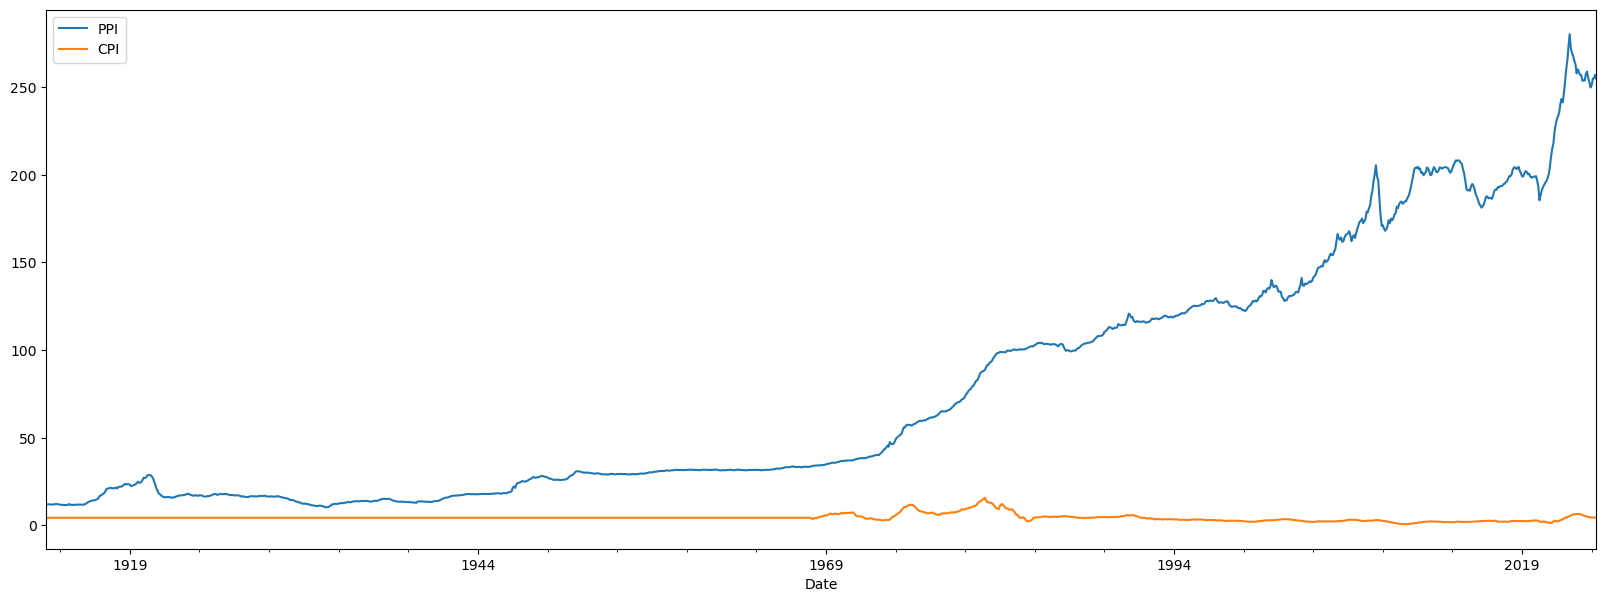

In [13]:
# Trend Analysis: Identify long-term trends, seasonal patterns, and cyclical behavior in the data.
df.plot(figsize=(20, 7))
plt.show()


